# Encoder-Only Transformer model

**Auteur**: `Jakob De Vreese`  
**Bachelorproef**: Overdraagbare unsupervised anomaliedetectie bij hybride HVAC-systemen  
**Academiejaar**: `2025-2026`  

## Doel

Bouwen en trainen van een **Encoder-Only Transformer Model** zoals gepresenteerd in *Transformer encoder based self-supervised learning for HVAC fault detection with unlabeled data* [(Abdollah et al., 2024)](http://dx.doi.org/10.1016/j.buildenv.2024.111568}). 

Dit model _wijkt af_ van de standaard **encoder-decoder architectuur** omdat anomaliedetectie in tijdreeksen **geen generatieve taak** is, wat de rekenkundige efficiëntie aanzienlijk verbetert. Het model maakt gebruik van _self-supervised learning_ via het `strategisch maskeren` van data.

### Verwachte brondata

Pre-processed multivariate dataset met HVAC-systeemdata (bijv. 10-minuten resolutie).

### Methodologische Kernconcepten
* **Time2Vec**: Voor het _inbedden_ van de temporele structuur (timestamps) in het model, aangezien een transformer van nature geen notie heeft van volgorde.
* **Markov Chain Masking**: Een autoregressieve pre-training taak waarbij _aaneengesloten segmenten_ van variabelen verborgen worden.
* **Peak Over Threshold (POT)**: Een statistische methode gebaseerd op de _Generalized Pareto Distribution_ (GPD) om dynamisch en automatisch de drempelwaarde voor anomalieën te bepalen.

### Stappenplan

- **Stap 1**: Data Preprocessing (Normalisatie & creatie van sliding windows)
- **Stap 2**: De Encoder-Only Architectuur (Keras/TensorFlow implementatie inclusief Time2Vec. Door de decoder weg te laten halveren we de wiskundige berekeningen)
- **Stap 3**: Self-Supervised Training (Markov chain block masking & MSE-loss)
- **Stap 4**: Keras Training via overschreven `train_step`
- **Stap 5**: Hyperparameter Tuning (KerasTuner) & Model Opslaan
- **Stap 6**: Inferentie & Anomaliescores
- **Stap 7**: Validatie met Hybride Data

In [35]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
import math
from scipy.stats import genpareto
import time
import os
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_recall_fscore_support,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    accuracy_score, balanced_accuracy_score, matthews_corrcoef
)
import keras_tuner as kt
import seaborn as sns

In [ ]:
# Herbruikbare evaluatie-toolbox voor alle architecturen (encoder-only / dv-mppca / TranAD)
def make_window_labels(y_timestep, window_size, stride=1, mode='fraction', frac_threshold=0.2):
    y_timestep = np.asarray(y_timestep).astype(int)
    labels = []
    for i in range(0, len(y_timestep) - window_size + 1, stride):
        w = y_timestep[i:i + window_size]
        if mode == 'max':
            labels.append(int(np.max(w) > 0))
        elif mode == 'center':
            labels.append(int(w[window_size // 2] > 0))
        elif mode == 'fraction':
            labels.append(int(np.mean(w) >= frac_threshold))
        else:
            raise ValueError("mode moet 'max', 'center' of 'fraction' zijn")
    return np.asarray(labels, dtype=int)


def find_event_segments(y_binary):
    y = np.asarray(y_binary).astype(int)
    segments = []
    in_seg = False
    start = 0
    for idx, v in enumerate(y):
        if v == 1 and not in_seg:
            in_seg = True
            start = idx
        elif v == 0 and in_seg:
            segments.append((start, idx - 1))
            in_seg = False
    if in_seg:
        segments.append((start, len(y) - 1))
    return segments


def event_based_metrics(y_true_binary, y_pred_binary):
    true_events = find_event_segments(y_true_binary)
    pred_events = find_event_segments(y_pred_binary)

    matched_true = 0
    for ts, te in true_events:
        overlap = any(not (pe < ts or ps > te) for ps, pe in pred_events)
        matched_true += int(overlap)

    matched_pred = 0
    for ps, pe in pred_events:
        overlap = any(not (te < ps or ts > pe) for ts, te in true_events)
        matched_pred += int(overlap)

    event_recall = matched_true / len(true_events) if len(true_events) else 0.0
    event_precision = matched_pred / len(pred_events) if len(pred_events) else 0.0
    if event_precision + event_recall == 0:
        event_f1 = 0.0
    else:
        event_f1 = 2.0 * event_precision * event_recall / (event_precision + event_recall)

    return {
        'event_precision': event_precision,
        'event_recall': event_recall,
        'event_f1': event_f1,
        'n_true_events': len(true_events),
        'n_pred_events': len(pred_events),
        'matched_true_events': matched_true,
        'matched_pred_events': matched_pred,
    }


def build_reusable_scorecard(y_true_window, scores_window, threshold, model_name='model'):
    y_true_window = np.asarray(y_true_window).astype(int)
    scores_window = np.asarray(scores_window).astype(float)
    y_pred_window = (scores_window > threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_window, y_pred_window, average='binary', zero_division=0
    )
    cm = confusion_matrix(y_true_window, y_pred_window)
    accuracy = accuracy_score(y_true_window, y_pred_window)
    balanced_acc = balanced_accuracy_score(y_true_window, y_pred_window)
    mcc = matthews_corrcoef(y_true_window, y_pred_window)
    roc_auc = roc_auc_score(y_true_window, scores_window) if len(np.unique(y_true_window)) > 1 else np.nan
    pr_auc = average_precision_score(y_true_window, scores_window) if len(np.unique(y_true_window)) > 1 else np.nan

    evt = event_based_metrics(y_true_window, y_pred_window)

    metrics_df = pd.DataFrame({
        'Model': [model_name] * 11,
        'Metric': [
            'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1',
            'MCC', 'ROC-AUC', 'PR-AUC', 'Event Precision', 'Event Recall', 'Event F1'
        ],
        'Value': [
            accuracy, balanced_acc, precision, recall, f1,
            mcc, roc_auc, pr_auc, evt['event_precision'], evt['event_recall'], evt['event_f1']
        ]
    })

    return {
        'threshold': float(threshold),
        'metrics_df': metrics_df,
        'confusion_matrix': cm,
        'y_pred_window': y_pred_window,
        'event_details': evt,
    }


def tune_threshold_by_f1(scores, y_true, q_low=0.90, q_high=0.999, n=250):
    scores = np.asarray(scores).astype(float)
    y_true = np.asarray(y_true).astype(int)
    candidates = np.unique(np.quantile(scores, np.linspace(q_low, q_high, n)))

    best_t = float(candidates[0])
    best_f1 = -1.0
    for t in candidates:
        y_hat = (scores > t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_true, y_hat, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1 = float(f1)
            best_t = float(t)
    return best_t, best_f1

## STAP 1 - Data Preprocessing

Voordat de data in het Keras-model wordt gevoed, wordt de volgende voorbereiding uitgevoerd:

1. **Data inlezen**
2. **Chronologische opsplitsing:** De tijdreeks wordt chronologisch opgesplitst (80% / 20%) om datalekkage te voorkomen.
3. **Standaardisatie:** De `StandardScaler` wordt uitsluitend gefit op de trainingsdata. Beide sets worden hiermee getransformeerd zodat het model geen statistieken van de testset leert.
4. **Sliding Windows:** Tijdreeksdata wordt opgedeeld in vaste *sliding windows*. De paper gebruikt een windowgrootte die exact overeenkomt met één dag. Bij een resolutie van 10 minuten is de `WINDOW_SIZE` 144.

### 1.1 Dataset inlezen

In [6]:
# Dataset inlezen
GEBOUW = 'dunant1'

url = f'../02_eda_en_ground_truth/processed/{GEBOUW}_train.csv'
data = pd.read_csv(url)
data.head()

,timestamp,f_1,f_2,f_3,f_4,f_6,f_7,f_8,f_9,f_10,...,f_50,f_51,f_52,f_53,f_54,f_55,is_weekdag,is_weekend,is_werkuur,uur
0,2026-03-09 00:10:00+00:00,7.0,0.77,1.0,39.877285,31.832268,1.0,23.594538,44.640636,1.0,...,0.0,3.851797,99.589400,0.749325,86.946641,0.0,1,0,0,0
1,2026-03-09 00:20:00+00:00,9.0,0.78,1.0,41.921010,34.104786,1.0,46.930084,44.640636,1.0,...,0.0,3.903977,100.000000,0.559565,45.771835,0.0,1,0,0,0
2,2026-03-09 00:30:00+00:00,8.0,0.86,1.0,43.412975,35.585346,1.0,43.235270,44.640636,0.0,...,0.0,4.244891,99.196013,0.322963,91.228401,0.0,1,0,0,0
3,2026-03-09 00:40:00+00:00,7.0,0.78,1.0,43.734930,35.924030,1.0,48.845810,44.640636,0.0,...,0.0,4.448537,98.800579,0.300000,323.796930,0.0,1,0,0,0
4,2026-03-09 00:50:00+00:00,9.0,0.78,1.0,44.037724,36.229050,1.0,44.068630,44.640636,0.0,...,0.0,4.748848,99.259927,0.345344,204.933704,0.0,1,0,0,0


In [7]:
print(data.shape)

(6997, 59)


### 1.2 Chronologische Train/Test split (80/20)

In [8]:
# Drop timestamp
if 'timestamp' in data.columns:
    data = data.drop(columns='timestamp')

# Splitsen in training en test (80% en 20%)
split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (5597, 58)
Test data shape: (1400, 58)


### 1.3 Normalisatie van de data

In de paper spreekt men van standaardnormalisatie per **feature** voor de hele trainingsdataset. We gebruiken hiervoor de `StandardScaler()` van `scikit-learn`.

In [9]:
scaler = StandardScaler()
train_norm = scaler.fit_transform(train_data)
test_norm = scaler.transform(test_data) # Pas de normalisatie ook toe op de testdata

### 1.4 Sliding windows maken

In de paper spreekt men van een _window-size_ van $96$ tijdstappen, wat voor hun data overeenkomt met 1 dag.

In [ ]:
WINDOW_SIZE = 144   # 1 dag data op 10-minutenbasis

In [43]:
# Hulpfunctie
def create_windows(data_array, window_size, step=1):
    windows = []
    # De step-parameter zorgt voor de verschuiving (stride)
    for i in range(0, len(data_array) - window_size + 1, step):
        windows.append(data_array[i : i + window_size])
    return np.array(windows)

In [13]:
X_train_all = create_windows(train_norm, WINDOW_SIZE)
X_test = create_windows(test_norm, WINDOW_SIZE)

# Extra validatieset uit het einde van de train windows (chronologisch, geen shuffle)
val_ratio = 0.15
val_start = int(len(X_train_all) * (1 - val_ratio))
X_train = X_train_all[:val_start]
X_val = X_train_all[val_start:]

print(f"Vorm van de training data (X_train): {X_train.shape}")
print(f"Vorm van de validatie data (X_val): {X_val.shape}")
print(f"Vorm van de test data (X_test): {X_test.shape}")

Vorm van de training data (X_train): (4635, 144, 58)
Vorm van de validatie data (X_val): (819, 144, 58)
Vorm van de test data (X_test): (1257, 144, 58)


Vorm van de tensor -> (aantal windows, tijdstappen per window, features)

## STAP 2 - De Encoder-Only Architectuur (Keras)

De paper kiest voor een architectuur die _uitsluitend_ uit een **encoder** bestaat. Omdat anomaliedetectie in deze context **geen generatieve taak** is (zoals taalvertaling of tekstgeneratie), is een decoder overbodig. Dit reduceert de complexiteit van het model en maakt de berekeningen aanzienlijk efficiënter.

We bouwen deze architectuur modulair op in vier stappen:

1. Hyperparameters definiëren
2. Time2Vec temporele encodering
3. De Transformer Encoder Laag
4. Het volledige model samenstellen

### 2.1 Hyperparameters

We nemen de specifieke dimensies en netwerkinstellingen over zoals beschreven in het onderzoek. De data wordt eerst geprojecteerd naar een interne dimensie (`d_model`), waarna het door multi-head attention blokken gaat.

* **`DIM_MODEL`**: De verborgen dimensie van het netwerk. We kiezen $140$ omdat dit deelbaar is door het aantal heads. Dit is een lineaire transformatie die de 54 features omzet in een abstracte vector van 140 getallen.
* **`NUM_HEADS`**: De paper gebruikt $7$ attention heads. In plaats van alle 140 dimensies in één keer te analyseren, deelt het model deze op in 7 parallelle _heads_. Het concept hier is dat elke _head_ zich zal _specialiseren_ in een ander type patroon (kortetermijn, dag/nacht-cyclus,...).
* **`NUM_LAYERS`**: Er worden $2$ opeenvolgende transformer-encoder lagen gebruikt. Dit representateert de _diepte_ van het netwerk. Het bepaalt hoeveel `Transformer-encoder` blokken er achter elkaar worden gestapeld. De paper gebruikt 2 lagen, omdat dit voor hun specifieke HVAC-data de beste balans biedt.

In [14]:
DIM_MODEL = 140
NUM_HEADS = 7    # Zoals in de paper
NUM_LAYERS = 2   # Zoals in de paper

### 2.2 Time2Vec (Temporele Encodering)

Een standaard Transformer bezit geen ingebouwd besef van de volgorde van data (tijd). Meestal wordt dit opgelost met statische sinus/cosinus positionele encoderingen. De paper kiest echter expliciet voor **Time2Vec** (Kazemi et al., 2019, geciteerd in de studie). 

Time2Vec is een model-agnostische vectorrepresentatie voor tijd die leerbare parameters bevat. Het vangt zowel lineaire trends als periodieke (seizoensgebonden) patronen op. De output van deze laag wordt opgeteld bij de geprojecteerde inputfeatures.

De formule bestaat uit twee componenten:
* Een lineaire component: $\tau \cdot w_0 + b_0$
* Een periodieke component (sinus): $\sin(\tau \cdot w + b)$

In [15]:
class Time2Vec(layers.Layer):
    def __init__(self, d_model, **kwargs):
        super(Time2Vec, self).__init__(**kwargs)
        self.d_model = d_model

    def build(self, input_shape):
        # Lineaire parameters (voor de niet-periodieke trend)
        self.w0 = self.add_weight(shape=(1, 1), initializer='random_normal', trainable=True, name='w0')
        self.b0 = self.add_weight(shape=(1, 1), initializer='random_normal', trainable=True, name='b0')
        
        # Periodieke parameters (sinus voor cyclische patronen)
        self.w = self.add_weight(shape=(1, self.d_model - 1), initializer='random_normal', trainable=True, name='w')
        self.b = self.add_weight(shape=(1, self.d_model - 1), initializer='random_normal', trainable=True, name='b')

    def call(self, tau):
        # tau is de input tijdstap matrix met shape: (batch_size, window_size, 1)
        v1 = tau * self.w0 + self.b0
        v2 = tf.math.sin(tau * self.w + self.b)
        
        # Concateneer de lineaire en periodieke representaties tot de d_model dimensie
        return tf.concat([v1, v2], axis=-1)

### 2.3 De Transformer Encoder Laag

Een enkel encoder-blok bestaat uit twee hoofdcomponenten, elk gevolgd door een *residual connection* (Add) en *Layer Normalization* (Norm):

1.  **Multi-Head Self-Attention**: Bepaalt hoe belangrijk elke tijdstap is ten opzichte van alle andere tijdstappen binnen hetzelfde window van 144 stappen.
2.  **Feed Forward Network (FFN)**: Een simpel neuraal netwerk dat de representaties verder transformeert. De dimensie wordt tijdelijk vergroot ($d\_model \times 4$) en dan weer teruggebracht.

In [16]:
class TransformerEncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, ffn_expansion=4, **kwargs):
        super(TransformerEncoderLayer, self).__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        
        # Feed-forward netwerk met dynamische expansiefactor (standaard 4)
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_model * ffn_expansion, activation='relu'),
            layers.Dense(d_model)
        ])
        
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x):
        attn_output = self.mha(x, x)
        out1 = self.layernorm1(x + attn_output)
        
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2

### 2.4 Het Volledige Transformer Model Samenstellen

Nu brengen we de onderdelen samen in de hoofdarchitectuur. De stroom van de data ($x$) verloopt als volgt:

1.  **Input Projectie**: De ruwe sensordata (bijv. 54 features) wordt lineair geprojecteerd naar de dimensie `d_model`. Dit gebeurt via een gewone `Dense` laag.
2.  **Positie Integratie**: De Time2Vec matrix wordt berekend op basis van de tijdstappen ($\tau$) en opgeteld bij de geprojecteerde input.
3.  **Encoder Blokken**: De resulterende matrix wordt iteratief door de `NUM_LAYERS` (2) encoder-lagen gestuurd.
4.  **Output Projectie**: De uiteindelijke output van de encoder wordt terug lineair geprojecteerd naar de originele feature-dimensie ($m = 54$) om de reconstructie te vormen.

In [21]:
class HVACAnomalyTransformer(Model):
    def __init__(self, num_features, d_model=DIM_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS, ffn_expansion=4, mask_ratio=0.15, block_len=3, **kwargs):
        super(HVACAnomalyTransformer, self).__init__(**kwargs)
        self.num_features = num_features
        self.mask_ratio = mask_ratio
        self.block_len = block_len
        
        self.input_projection = layers.Dense(d_model)
        self.time2vec = Time2Vec(d_model)
        
        self.encoder_layers = [
            TransformerEncoderLayer(d_model, num_heads, ffn_expansion=ffn_expansion) for _ in range(num_layers)
        ]
        
        self.output_projection = layers.Dense(num_features)
        
        # Interne metrics tracker voor de custom loss
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, x, training=False):
        window_size = tf.shape(x)[1]
        
        # Broadcasting lost de batch-dimensie op, we besparen geheugen door tf.tile weg te laten
        tau = tf.range(window_size, dtype=tf.float32)
        tau = tf.reshape(tau, (1, window_size, 1))
        
        u = self.input_projection(x)
        w_pos = self.time2vec(tau)
        z = u + w_pos
        
        for encoder_layer in self.encoder_layers:
            z = encoder_layer(z)
            
        reconstructed = self.output_projection(z)
        return reconstructed

    def train_step(self, data):
        # We hebben geen (x, y) tupel omdat dit unsupervised is, data bevat direct batch_x
        batch_x = data
        batch_size = tf.shape(batch_x)[0]
        window_size = tf.shape(batch_x)[1]
        
        # Dynamisch masker genereren per batch
        mask = create_block_mask_tf(batch_size, window_size, self.num_features, self.mask_ratio, self.block_len)
        masked_x = batch_x * mask
        
        with tf.GradientTape() as tape:
            reconstructed = self(masked_x, training=True)
            loss = masked_mse_loss_tf(batch_x, reconstructed, mask)
            
        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        batch_x = data
        batch_size = tf.shape(batch_x)[0]
        window_size = tf.shape(batch_x)[1]
        
        mask = create_block_mask_tf(batch_size, window_size, self.num_features, self.mask_ratio, self.block_len)
        masked_x = batch_x * mask
        
        reconstructed = self(masked_x, training=False)
        loss = masked_mse_loss_tf(batch_x, reconstructed, mask)
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

In [28]:
# Initialisatie ter controle
NUM_FEATURES = X_train.shape[-1]
model = HVACAnomalyTransformer(num_features=NUM_FEATURES)
model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES)))

model.summary()

Model: "hvac_anomaly_transformer_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (1, 144, 140)          │         8,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time2_vec_2 (Time2Vec)          │ ?                      │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_4     │ ?                      │       709,940 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_5     │ ?                      │       709,940 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (1, 144, 58)           │         8,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,436,598 (5.48 MB)

 Trainable params: 1,436,598 (5.48 MB)

 Non-trainable params: 0 (0.00 B)

## STAP 3 - Self-Supervised Training (Masking & Loss)

Omdat het verzamelen van gelabelde foutdata (waarbij een expert voor elke minuut heeft aangeduid of het HVAC-systeem correct werkt) in de praktijk extreem duur of onmogelijk is, gebruikt deze paper **Self-Supervised Learning (SSL)**. 

In plaats van het model te trainen op externe labels, creëren we een interne taak: we verbergen (maskeren) opzettelijk delen van de perfect normale trainingsdata en vragen het model om deze ontbrekende stukken in te vullen. Hierdoor wordt het model gedwongen om de onderliggende fysieke en thermodynamische wetten van het gebouw te leren.

Deze stap bestaat uit twee kernconcepten:

1. Het genereren van een Markov Chain blok-masker.
2. Het berekenen van de reconstructiefout uitsluitend op de gemaskeerde delen.

### 3.1 Markov Chain Block Masking

Een naïeve manier van maskeren is het willekeurig weglaten van individuele datapunten (zoals in standaard taalmodellen). Echter, HVAC-data is een tijdreeks met een hoge traagheid (bijv. de temperatuur in een kamer verandert heel langzaam). Als we slechts één tijdstap verbergen, kan het model de waarde simpelweg raden door het gemiddelde te nemen van de seconde ervoor en erna, zonder iets wezenlijks te leren.

De auteurs (Abdollah et al., 2024) lossen dit op door **Markov Chain Masking** toe te passen. Dit betekent dat we niet zomaar losse punten verbergen, maar aaneengesloten *segmenten* (blokken). Het model moet nu uren aan ontbrekende data voorspellen, wat dwingt tot een dieper begrip van de lange-termijn trends.

Parameters uit de paper:

* **Maskeerratio ($r$)**: Het percentage van de data dat we verbergen (ingesteld op $15\%$).
* **Gemiddelde bloklengte ($l_m$)**: De gemiddelde lengte van een aaneengesloten gemaskeerd segment (ingesteld op $3$ tijdstappen).

In [23]:
# Instelbare parameters
MASKEERRATIO = 0.15
GEMIDDELDE_BLOKLENGTE = 3

In [24]:
@tf.function
def create_block_mask_tf(batch_size, window_size, num_features, r=0.15, l_m=3):
    """
    Gevectoriseerde Keras-implementatie. Genereert instant een masker via 1D Max Pooling.
    Waarde 1.0 = zichtbaar, 0.0 = gemaskeerd.
    """
    # Kans op de start van een maskerblok
    p_start = r / float(l_m)
    
    # 1. Genereer random uniform tensor
    rand_tensor = tf.random.uniform((batch_size, window_size, num_features))
    
    # 2. Bepaal startpunten (1.0 waar een blok start, anders 0.0)
    block_starts = tf.cast(rand_tensor < p_start, tf.float32)
    
    # 3. Smeer de startpunten uit over lengte l_m via Max Pooling
    smeared = tf.nn.max_pool1d(block_starts, ksize=l_m, strides=1, padding='SAME')
    
    # 4. Inverteer het masker zodat zichtbaar = 1.0 en gemaskeerd = 0.0
    mask = 1.0 - smeared
    return mask

### 3.2 Doelgerichte Verliesfunctie (Masked MSE)

Normaal berekent een autoencoder zijn verlies (Mean Squared Error) door de volledige input te vergelijken met de volledige output. 

De paper benadrukt echter dat de verliesfunctie **uitsluitend berekend mag worden over de gemaskeerde (verborgen) segmenten**. 

* **Waarom?** Als we het model ook zouden straffen voor fouten op de ongemaskeerde data (die het model gewoon als input krijgt), moedigen we het netwerk aan om een "identiteitsfunctie" te leren. Het zou simpelweg de input direct naar de output kopiëren zonder echt iets te snappen van het HVAC-systeem. Door alleen de loss op de verborgen delen te berekenen, meten we pure *voorspellende intelligentie*.

In [25]:
@tf.function
def masked_mse_loss_tf(original, reconstructed, mask):
    """
    Berekent de Mean Squared Error (MSE) exclusief over de gemaskeerde waarden.
    
    Parameters:
    - original: De originele, ongecensureerde data
    - reconstructed: De voorspelling van het model
    - mask: 1.0 = zichtbaar (mag niet meetellen), 0.0 = gemaskeerd (moet meetellen)
    """
    # 1. Inverteer het masker: 1 wordt 0, en 0 wordt 1.
    # Nu hebben alleen de posities die we moesten voorspellen de waarde 1.
    inverted_mask = 1.0 - mask
    
    # 2. Bereken de standaard kwadratische fout voor het volledige window
    squared_error = tf.square(reconstructed - original)
    
    # 3. Filter de fouten: vermenigvuldig met inverted_mask. 
    # Fouten op plekken die het model al kende, worden hiermee vermenigvuldigd met 0 en vallen weg.
    masked_squared_error = squared_error * inverted_mask
    
    # 4. Bereken het gemiddelde. We delen de totale som van de relevante fouten 
    # door het exacte aantal elementen dat we effectief verborgen hadden.
    # (1e-8 voorkomt een error wegens delen door nul)
    loss = tf.reduce_sum(masked_squared_error) / (tf.reduce_sum(inverted_mask) + 1e-8)
    
    return loss

## STAP 4 - De Trainingsloop

Omdat we in de vorige stap een dynamisch Markov Chain masker en een aangepaste verliesfunctie hebben gedefinieerd, is de standaard `model.fit()` methode van Keras niet langer toereikend. We bouwen in plaats daarvan een **Custom Training Loop**. 

Dit stelt ons in staat om voor elke individuele batch (een klein deel van de data) on-the-fly een nieuw, willekeurig masker te genereren en de optimalisatie van het netwerk handmatig te beheren met `tf.GradientTape`.

We bouwen dit op in drie logische delen:
1. Hyperparameters & Datavoorbereiding
2. De fundamentele trainingsstap (verwerking van één batch)
3. De iteratieve loop over de epochs

### 4.1 Hyperparameters & Datavoorbereiding

We definiëren de standaardvariabelen voor de training. De paper specificeert de Adam-optimizer, die bijzonder goed werkt met Transformer-architecturen.

Daarnaast verpakken we onze ruwe `numpy` arrays in een `tf.data.Dataset` object. Dit zorgt voor zeer efficiënte data-invoer naar de GPU/CPU. Het model verwerkt de data niet raam per raam, maar in batches (bijv. 32 windows tegelijk). We schudden (*shufflen*) de batches willekeurig door elkaar. Dit is toegestaan en voorkomt dat het model zich vastpint op de chronologische volgorde van de dagen; de temporele volgorde *binnen* elk window van 144 stappen is immers al behouden.

In [26]:
# Hyperparameters
NUM_EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 1e-4

In [27]:
# We casten de data expliciet naar float32 voor compatibiliteit met Keras/TensorFlow
X_train_tf = tf.cast(X_train, tf.float32)
X_val_tf = tf.cast(X_val, tf.float32)

# TensorFlow Datasets aanmaken voor efficiënte batching en shuffling
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_tf)
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(X_val_tf).batch(BATCH_SIZE)

# Optimizer initialiseren
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

### 4.3 De Iteratieve Epoch Loop

Een *epoch* is voltooid wanneer het model de volledige dataset (`train_dataset`) exact één keer heeft doorlopen in batches. We itereren over het gedefinieerde aantal epochs en houden de gemiddelde foutmarge (loss) per epoch bij. Als de training correct verloopt, zou deze gemiddelde loss na elke epoch stapsgewijs moeten dalen totdat het model convergeert.

In [29]:
print("Start van de training...")

# Optimizer koppelen aan het model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE))

# Callback voor automatische stop als de validatie loss niet meer verbetert
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

# Trainen met de ingebouwde fit-methode
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=NUM_EPOCHS,
    callbacks=[early_stopping]
)

print("Training voltooid.")

Start van de training...
Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 113s 752ms/step - loss: 0.5833 - val_loss: 0.2941
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 113s 779ms/step - loss: 0.2454 - val_loss: 0.2179
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 113s 779ms/step - loss: 0.1797 - val_loss: 0.1738
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 117s 804ms/step - loss: 0.1484 - val_loss: 0.1456
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 120s 825ms/step - loss: 0.1278 - val_loss: 0.1265
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 118s 815ms/step - loss: 0.1154 - val_loss: 0.1153
Epoch 7/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 117s 806ms/step - loss: 0.1068 - val_loss: 0.1077
Epoch 8/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 116s 801ms/step - loss: 0.0984 - val_loss: 0.1019
Epoch 9/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 117s 807ms/step - loss: 0.0929 - val_loss: 0.0957
Epoch 10/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 117s 805ms/step - loss: 0.0873 - val_loss: 0.0934
Training voltooid.


### 4.4 Evaluatie van het initieel getrainde model

Om de prestaties van het initieel getrainde model objectief te beoordelen, laden we opnieuw de gelabelde ground truth testset in. De timestep-labels worden omgezet naar window-level labels, zodat elk sliding window een binair label krijgt: normaal of anomalie. Daarna laten we het getrainde model reconstructies maken op deze gelabelde data, berekenen we de anomaliescore per window en vergelijken we die scores met een drempel die enkel uit de trainingsdata is afgeleid. Zo vermijden we dat de evaluatie zelf informatie uit de testlabels lekt. Deze baseline vormt later een directe vergelijking met het best getunede model uit Stap 5.

In [60]:
# 4.4.1 Ground truth en labels inladen
synth_csv = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test.csv'
labels_npy = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test_labels.npy'

synth_df = pd.read_csv(synth_csv)
y_true_timestep = np.load(labels_npy).astype(int)

# Verwijder mogelijke index- of timestampkolommen
if 'timestamp' in synth_df.columns:
    synth_df = synth_df.drop(columns=['timestamp'])

for col in list(synth_df.columns):
    if col.lower().startswith('unnamed'):
        synth_df = synth_df.drop(columns=[col])

# Zorg dat de kolommen exact overeenkomen met de trainingsfeatures
synth_df = synth_df[train_data.columns]

# Zelfde normalisatie als tijdens training
synth_norm = scaler.transform(synth_df)

In [61]:
# Maak sliding windows van de ground truth set
STRIDE = 4 # halve dag overlap

# Sliding windows bouwen
X_eval = create_windows(synth_norm, WINDOW_SIZE, step=STRIDE)

In [62]:
# Timestep-labels omzetten naar window-labels:
# een window is anomalie als minstens één timestep anomalie is
y_true_window = np.array(
    [1 if np.max(y_true_timestep[i:i + WINDOW_SIZE]) > 0 else 0
     for i in range(0, len(y_true_timestep) - WINDOW_SIZE + 1, STRIDE)],
    dtype=int
)

In [63]:
print(f"Eval rows: {synth_df.shape[0]}")
print(f"Eval windows: {X_eval.shape}")
print(f"Window labels: {y_true_window.shape}, anomalies={y_true_window.sum()}")

Eval rows: 778
Eval windows: (159, 144, 58)
Window labels: (159,), anomalies=88


In [64]:
# Scores op de validatieset gebruiken om de threshold te kalibreren
X_val_tf = tf.cast(X_val, tf.float32)
recon_val = model.predict(X_val_tf, batch_size=BATCH_SIZE, verbose=0)
val_scores = np.mean(np.sum(np.abs(recon_val - X_val), axis=-1), axis=1)

In [65]:
# Scores op de evaluatieset (gelabelde synthetische windows)
X_eval_tf = tf.cast(X_eval, tf.float32)
recon_eval = model.predict(X_eval_tf, batch_size=BATCH_SIZE, verbose=0)

In [66]:
eval_scores = np.mean(np.sum(np.abs(recon_eval - X_eval), axis=-1), axis=1)

In [67]:
baseline_threshold = np.percentile(val_scores, 99)

In [68]:
y_pred_eval = (eval_scores > baseline_threshold).astype(int)

print("val:", np.percentile(val_scores, [50, 90, 95, 99]))
print("eval:", np.percentile(eval_scores, [1, 5, 50, 95, 99]))
print("threshold:", baseline_threshold)
print("eval below threshold:", np.mean(eval_scores <= baseline_threshold))
print("shapes:", "y_true_window =", y_true_window.shape, "| y_pred_eval =", y_pred_eval.shape)

val: [10.8479318  13.66701927 14.05099127 14.5516921 ]
eval: [12.99309276 13.08803005 14.69547748 15.39377404 15.62729977]
threshold: 14.551692104445515
eval below threshold: 0.4025157232704403
shapes: y_true_window = (159,) | y_pred_eval = (159,)


In [69]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_window, y_pred_eval, average='binary', zero_division=0
)

cm = confusion_matrix(y_true_window, y_pred_eval)
tn, fp, fn, tp = cm.ravel()

roc_auc = roc_auc_score(y_true_window, eval_scores)
pr_auc = average_precision_score(y_true_window, eval_scores)
accuracy = accuracy_score(y_true_window, y_pred_eval)
balanced_acc = balanced_accuracy_score(y_true_window, y_pred_eval)
mcc = matthews_corrcoef(y_true_window, y_pred_eval)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "MCC",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy,
        balanced_acc,
        precision,
        recall,
        f1,
        mcc,
        roc_auc,
        pr_auc
    ]
})

print(metrics_df.to_string(index=False))
print("\nConfusion matrix:")
print(cm)

           Metric     Value
         Accuracy  0.477987
Balanced Accuracy  0.467190
        Precision  0.526316
           Recall  0.568182
               F1  0.546448
              MCC -0.066521
          ROC-AUC  0.483035
           PR-AUC  0.531135

Confusion matrix:
[[26 45]
 [38 50]]


/tmp/ipykernel_17178/2020935436.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


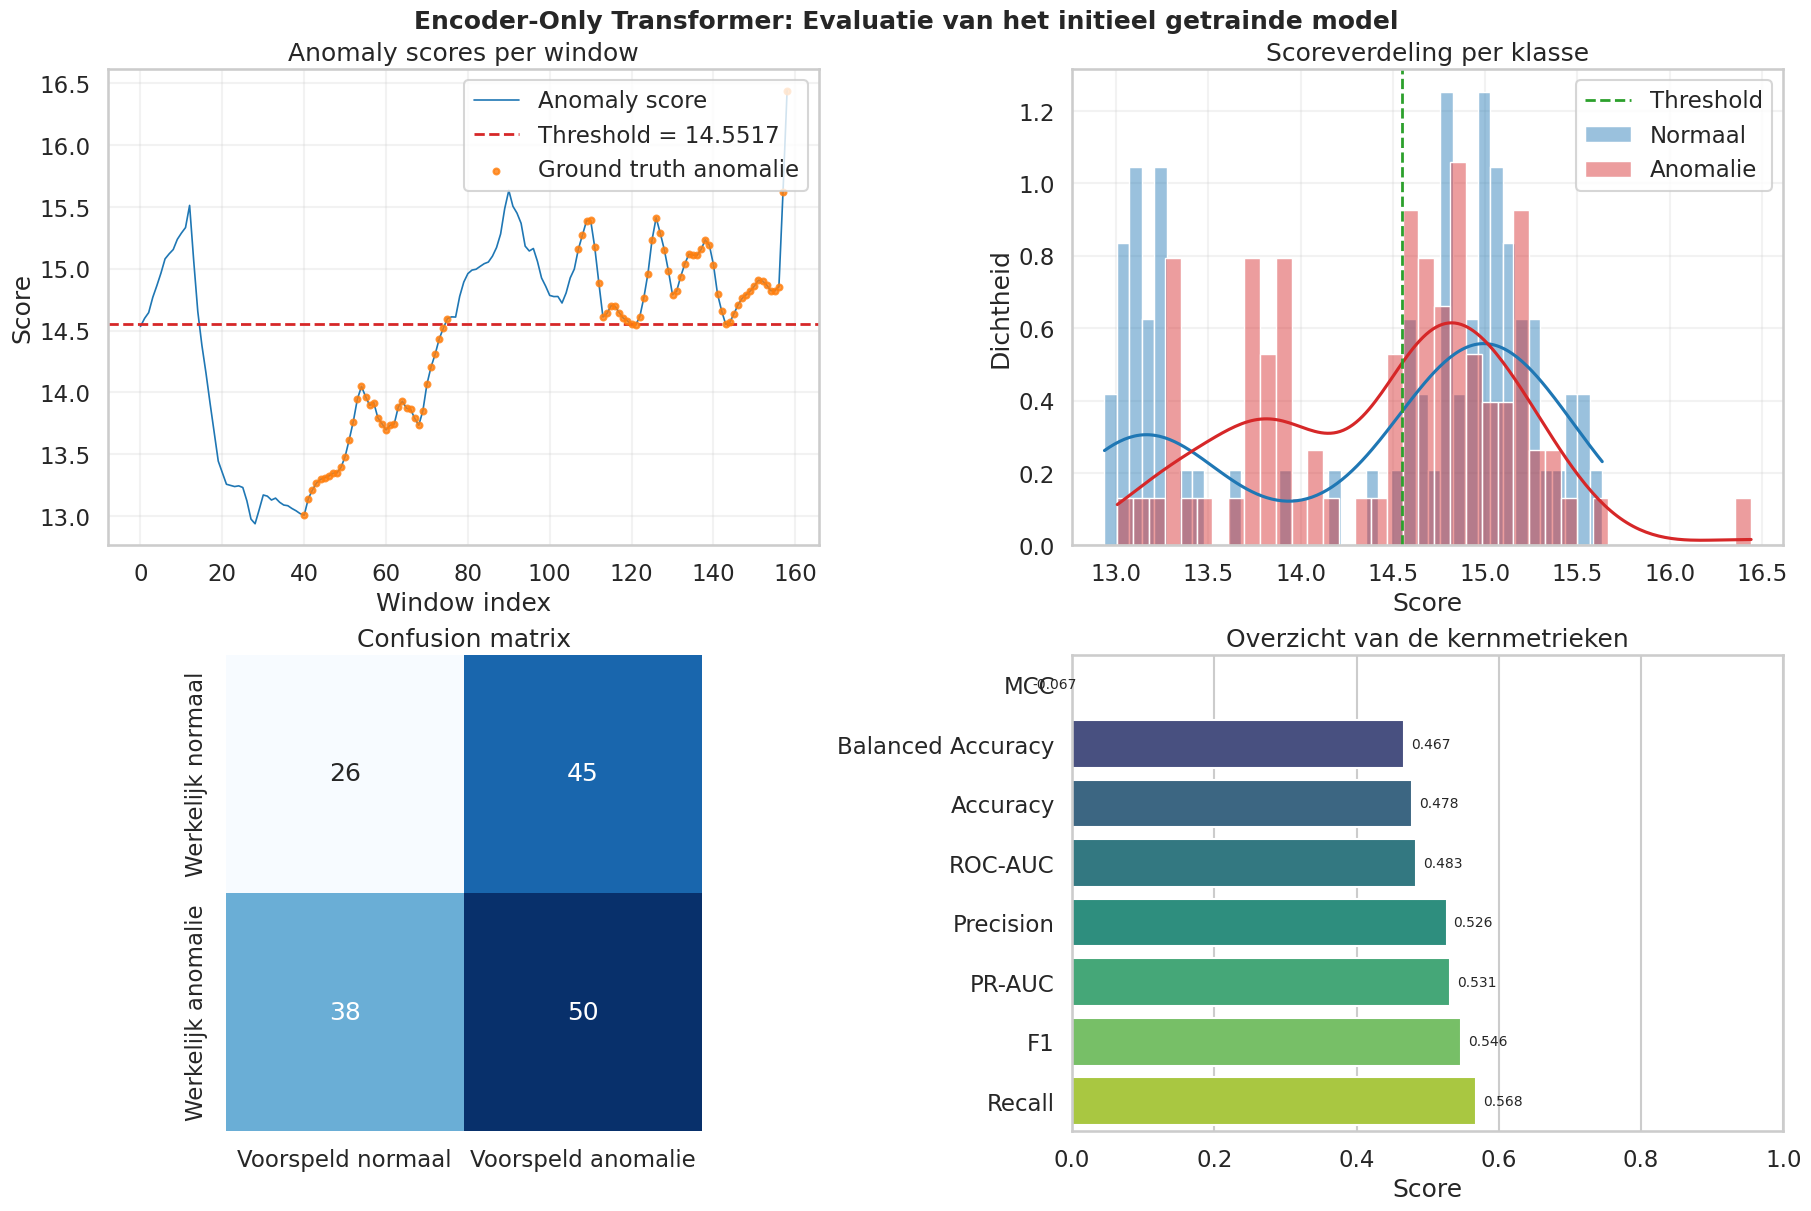

In [70]:
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle("Encoder-Only Transformer: Evaluatie van het initieel getrainde model", fontsize=18, fontweight="bold")

# Plot 1: anomaly scores over de windows
ax1 = axes[0, 0]
ax1.plot(eval_scores, color="#1f77b4", linewidth=1.2, label="Anomaly score")
ax1.axhline(baseline_threshold, color="#d62728", linestyle="--", linewidth=2, label=f"Threshold = {baseline_threshold:.4f}")

anom_idx = np.where(y_true_window == 1)[0]
ax1.scatter(
    anom_idx,
    eval_scores[anom_idx],
    s=18,
    color="#ff7f0e",
    alpha=0.8,
    label="Ground truth anomalie",
    zorder=5
)

ax1.set_title("Anomaly scores per window")
ax1.set_xlabel("Window index")
ax1.set_ylabel("Score")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.25)

# Plot 2: scoreverdeling per klasse
ax2 = axes[0, 1]
sns.histplot(eval_scores[y_true_window == 0], bins=40, kde=True, stat="density", color="#1f77b4", alpha=0.45, label="Normaal", ax=ax2)
sns.histplot(eval_scores[y_true_window == 1], bins=40, kde=True, stat="density", color="#d62728", alpha=0.45, label="Anomalie", ax=ax2)
ax2.axvline(baseline_threshold, color="#2ca02c", linestyle="--", linewidth=2, label="Threshold")
ax2.set_title("Scoreverdeling per klasse")
ax2.set_xlabel("Score")
ax2.set_ylabel("Dichtheid")
ax2.legend(loc="upper right")
ax2.grid(alpha=0.25)

# Plot 3: confusion matrix
ax3 = axes[1, 0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=["Voorspeld normaal", "Voorspeld anomalie"],
    yticklabels=["Werkelijk normaal", "Werkelijk anomalie"],
    ax=ax3
)
ax3.set_title("Confusion matrix")
ax3.set_xlabel("")
ax3.set_ylabel("")

# Plot 4: metric overview
ax4 = axes[1, 1]
metric_plot_df = metrics_df.copy()
metric_plot_df = metric_plot_df.sort_values("Value", ascending=True)

sns.barplot(
    data=metric_plot_df,
    x="Value",
    y="Metric",
    palette="viridis",
    ax=ax4
)

for i, value in enumerate(metric_plot_df["Value"]):
    ax4.text(min(value + 0.01, 1.02), i, f"{value:.3f}", va="center", fontsize=10)

ax4.set_xlim(0, max(1.0, metric_plot_df["Value"].max() + 0.15))
ax4.set_title("Overzicht van de kernmetrieken")
ax4.set_xlabel("Score")
ax4.set_ylabel("")

plt.show()

## STAP 5 - Hyperparameter Tuning & Model Opslaan

Omdat we een custom architectuur gebruiken, is het belangrijk om de juiste hyperparameters te vinden. Een volledige *Grid Search* (waarbij elke mogelijke combinatie wordt getest) is voor Transformers vaak te rekenintensief voor een standaard laptop. Daarom gebruiken we een gecontroleerde iteratieve zoektocht over een beperkt aantal logische combinaties (bijv. het aantal dimensies en attention heads).

Na de zoektocht slaan we het best presterende model op. Omdat we werken met Keras *Model Subclassing* (custom lagen zoals `Time2Vec`), is de meest robuuste methode het opslaan van de **modelgewichten** (weights) in plaats van het hele modelobject. Dit voorkomt serialisatiefouten bij het inladen.

In [71]:
def build_model(hp):
    # 1. Definieer de zoekruimte
    d_model = hp.Int('d_model', min_value=96, max_value=168, step=16)
    num_heads = hp.Choice('num_heads', values=[4, 7, 8])
    num_layers = hp.Int('num_layers', min_value=1, max_value=3)
    ffn_expansion = hp.Choice('ffn_expansion', values=[2, 4])
    lr = hp.Choice('learning_rate', values=[1e-3, 1e-4, 8e-5])
    mask_ratio = hp.Choice('mask_ratio', values=[0.15, 0.20])
    block_len = hp.Choice('block_len', values=[3, 4])
    
    # 2. Model instantiëren met de getunede parameters
    temp_model = HVACAnomalyTransformer(
        num_features=NUM_FEATURES,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        ffn_expansion=ffn_expansion,
        mask_ratio=mask_ratio,
        block_len=block_len
    )
    
    # 3. Dummy aanroep voor initialisatie en compileren
    temp_model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES))) 
    temp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr))
    
    return temp_model

# Configureer de Hyperband Tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=12,
    factor=3,
    directory='tuning_logs',
    project_name='hvac_encoder_tuning'
)

print("Start Hyperparameter Tuning met KerasTuner...")

# Zoek naar de beste hyperparameter set
tuner.search(
    train_dataset, 
    validation_data=val_dataset, 
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)]
)

# Het beste model en de parameters extraheren
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nBeste configuratie gevonden: {best_hps.values}")

Trial 30 Complete [00h 11m 27s]
val_loss: 0.14146801829338074

Best val_loss So Far: 0.07083331048488617
Total elapsed time: 03h 56m 39s

Beste configuratie gevonden: {'d_model': 160, 'num_heads': 8, 'num_layers': 1, 'ffn_expansion': 4, 'learning_rate': 0.001, 'mask_ratio': 0.2, 'block_len': 3, 'tuner/epochs': 12, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### 5.3 Snelle evaluatie beste model

In [72]:
# Scores op de validatieset gebruiken om de threshold te kalibreren
X_val_tf = tf.cast(X_val, tf.float32)
recon_val = best_model.predict(X_val_tf, batch_size=BATCH_SIZE, verbose=0)
val_scores_best = np.mean(np.sum(np.abs(recon_val - X_val), axis=-1), axis=1)

In [73]:
# Scores op de evaluatieset
X_eval_tf = tf.cast(X_eval, tf.float32)
recon_eval_best = best_model.predict(X_eval_tf, batch_size=BATCH_SIZE, verbose=0)
eval_scores_best = np.mean(np.sum(np.abs(recon_eval_best - X_eval), axis=-1), axis=1)

# Threshold op basis van de normale validatiescores
baseline_threshold_best = np.percentile(val_scores_best, 99)

In [74]:
# Binaire voorspellingen
y_pred_eval_best = (eval_scores_best > baseline_threshold_best).astype(int)

print("val:", np.percentile(val_scores_best, [50, 90, 95, 99]))
print("eval:", np.percentile(eval_scores_best, [1, 5, 50, 95, 99]))
print("threshold:", baseline_threshold_best)
print("eval below threshold:", np.mean(eval_scores_best <= baseline_threshold_best))
print("shapes:", "y_true_window =", y_true_window.shape, "| y_pred_eval_best =", y_pred_eval_best.shape)

val: [ 9.35433474 11.44213144 11.56443743 11.87263408]
eval: [11.12490615 11.20206443 12.91817973 13.67919347 14.25461681]
threshold: 11.8726340796703
eval below threshold: 0.3333333333333333
shapes: y_true_window = (159,) | y_pred_eval_best = (159,)


In [75]:
# Scorekaart
precision_best, recall_best, f1_best, _ = precision_recall_fscore_support(
    y_true_window, y_pred_eval_best, average='binary', zero_division=0
)

cm_best = confusion_matrix(y_true_window, y_pred_eval_best)
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()

roc_auc_best = roc_auc_score(y_true_window, eval_scores_best)
pr_auc_best = average_precision_score(y_true_window, eval_scores_best)
accuracy_best = accuracy_score(y_true_window, y_pred_eval_best)
balanced_acc_best = balanced_accuracy_score(y_true_window, y_pred_eval_best)
mcc_best = matthews_corrcoef(y_true_window, y_pred_eval_best)

metrics_best_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "MCC",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy_best,
        balanced_acc_best,
        precision_best,
        recall_best,
        f1_best,
        mcc_best,
        roc_auc_best,
        pr_auc_best
    ]
})

print(metrics_best_df.to_string(index=False))
print("\nConfusion matrix:")
print(cm_best)

           Metric     Value
         Accuracy  0.509434
Balanced Accuracy  0.491517
        Precision  0.547170
           Recall  0.659091
               F1  0.597938
              MCC -0.017891
          ROC-AUC  0.630282
           PR-AUC  0.751872

Confusion matrix:
[[23 48]
 [30 58]]


/tmp/ipykernel_17178/1420786170.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


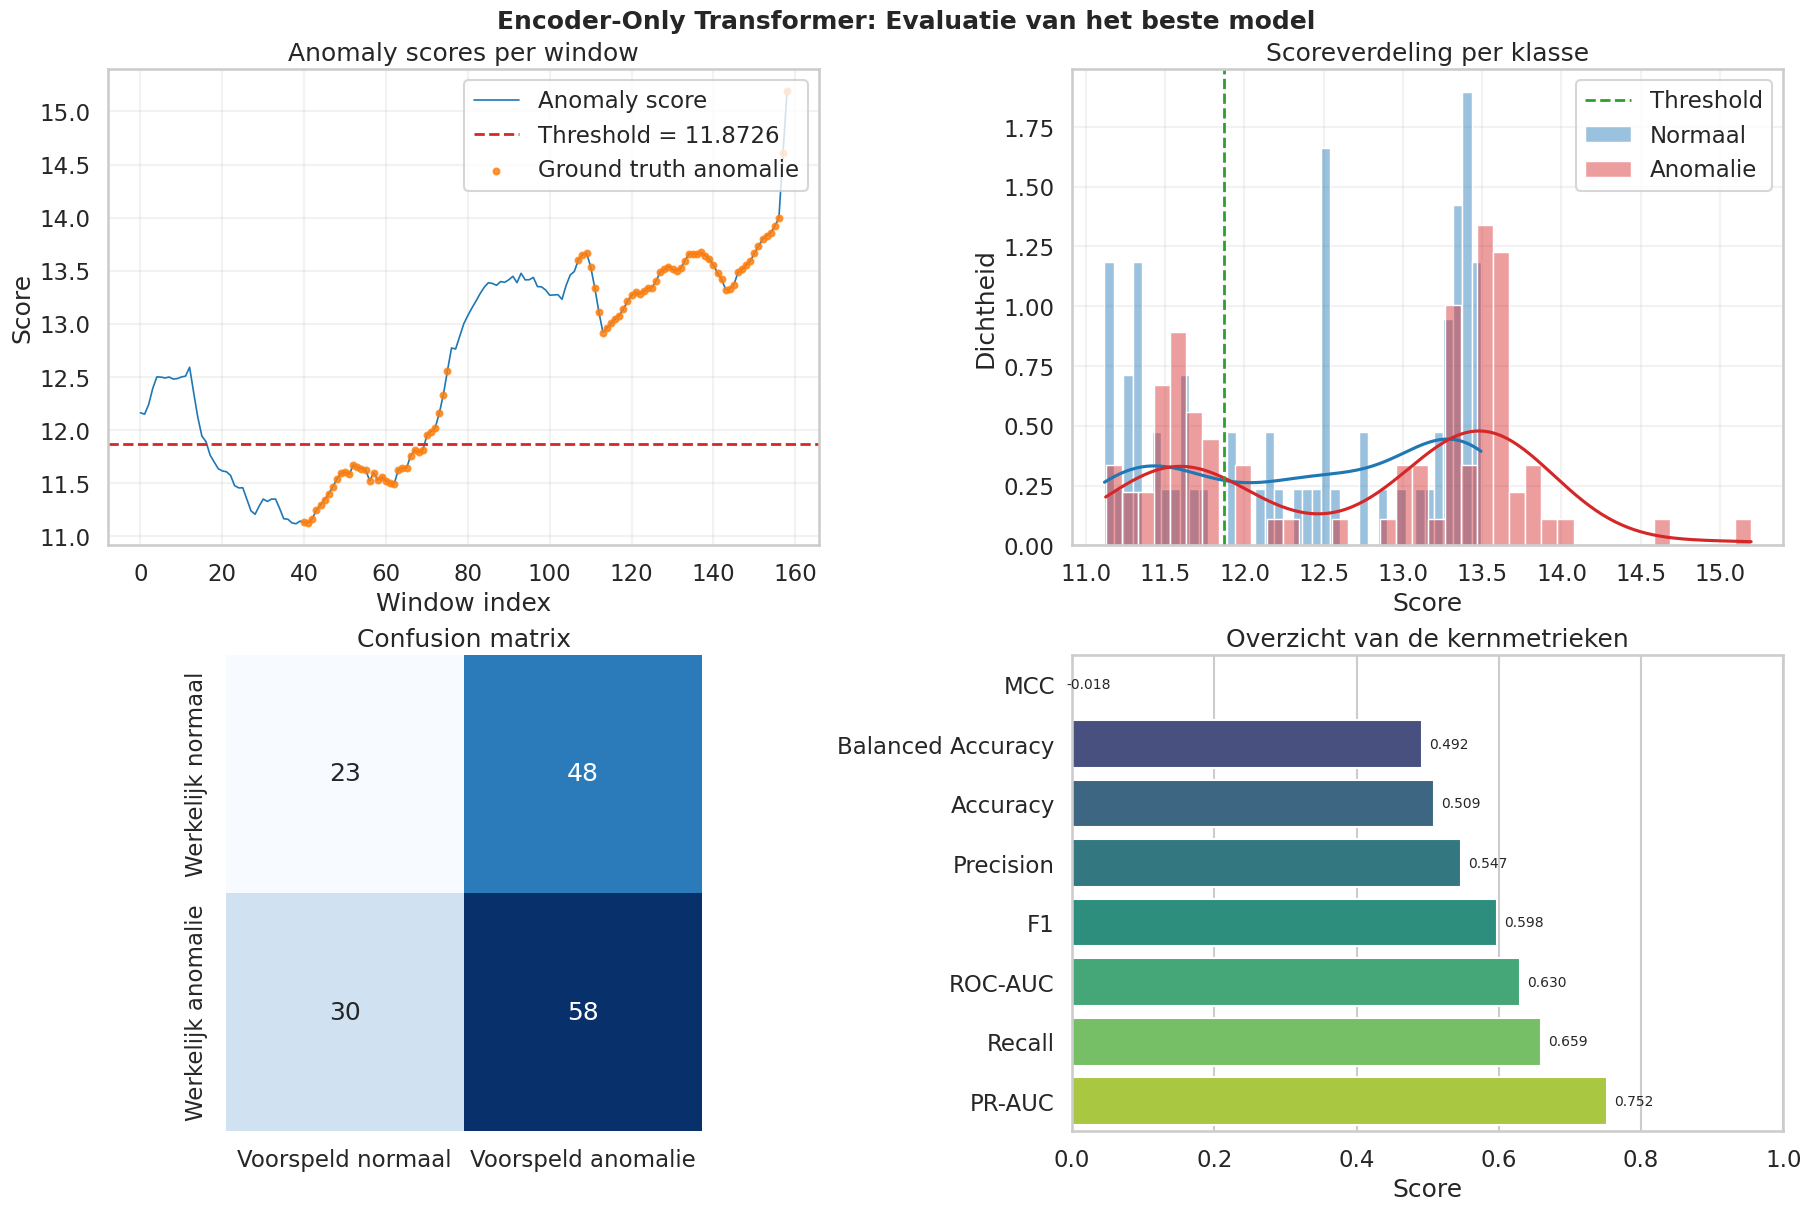

In [76]:
# Visualisaties
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle("Encoder-Only Transformer: Evaluatie van het beste model", fontsize=18, fontweight="bold")

# Plot 1: anomaly scores over de windows
ax1 = axes[0, 0]
ax1.plot(eval_scores_best, color="#1f77b4", linewidth=1.2, label="Anomaly score")
ax1.axhline(
    baseline_threshold_best,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {baseline_threshold_best:.4f}"
)

anom_idx = np.where(y_true_window == 1)[0]
ax1.scatter(
    anom_idx,
    eval_scores_best[anom_idx],
    s=18,
    color="#ff7f0e",
    alpha=0.8,
    label="Ground truth anomalie",
    zorder=5
)

ax1.set_title("Anomaly scores per window")
ax1.set_xlabel("Window index")
ax1.set_ylabel("Score")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.25)

# Plot 2: scoreverdeling per klasse
ax2 = axes[0, 1]
sns.histplot(
    eval_scores_best[y_true_window == 0],
    bins=40,
    kde=True,
    stat="density",
    color="#1f77b4",
    alpha=0.45,
    label="Normaal",
    ax=ax2
)
sns.histplot(
    eval_scores_best[y_true_window == 1],
    bins=40,
    kde=True,
    stat="density",
    color="#d62728",
    alpha=0.45,
    label="Anomalie",
    ax=ax2
)
ax2.axvline(baseline_threshold_best, color="#2ca02c", linestyle="--", linewidth=2, label="Threshold")
ax2.set_title("Scoreverdeling per klasse")
ax2.set_xlabel("Score")
ax2.set_ylabel("Dichtheid")
ax2.legend(loc="upper right")
ax2.grid(alpha=0.25)

# Plot 3: confusion matrix
ax3 = axes[1, 0]
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=["Voorspeld normaal", "Voorspeld anomalie"],
    yticklabels=["Werkelijk normaal", "Werkelijk anomalie"],
    ax=ax3
)
ax3.set_title("Confusion matrix")
ax3.set_xlabel("")
ax3.set_ylabel("")

# Plot 4: metric overview
ax4 = axes[1, 1]
metric_plot_df = metrics_best_df.sort_values("Value", ascending=True)

sns.barplot(
    data=metric_plot_df,
    x="Value",
    y="Metric",
    palette="viridis",
    ax=ax4
)

for i, value in enumerate(metric_plot_df["Value"]):
    ax4.text(min(value + 0.01, 1.02), i, f"{value:.3f}", va="center", fontsize=10)

ax4.set_xlim(0, max(1.0, metric_plot_df["Value"].max() + 0.15))
ax4.set_title("Overzicht van de kernmetrieken")
ax4.set_xlabel("Score")
ax4.set_ylabel("")

plt.show()

### 5.4 Beste model opslaan

In [77]:
# Model opslaan
gebouw_naam = "dunant1"
huidige_datum = datetime.now().strftime("%Y-%m-%d")
model_dir = "models"
os.makedirs(model_dir, exist_ok=True) 

save_path = f"{model_dir}/encoder-only-{gebouw_naam}-{huidige_datum}.weights.h5"
best_model.save_weights(save_path)

print(f"Beste model succesvol opgeslagen in: {save_path}")

Beste model succesvol opgeslagen in: models/encoder-only-dunant1-2026-05-02.weights.h5


## STAP 6 - Inferentie: Het model in de praktijk gebruiken

In deze stap simuleren we hoe het systeem in de praktijk wordt gebruikt. We gaan ervan uit dat het model op een server draait en nieuwe, onvoorziene gebouwdata binnenkrijgt.

We doen het volgende:

1. We initialiseren het model en laden de getrainde gewichten in.
2. We voeden de (normale) testdata aan het model en berekenen de reconstructiefout.
3. We gebruiken de **Peak Over Threshold (POT)** methode (op basis van de Generalized Pareto Distribution) om de "baseline" drempelwaarde voor dit specifieke gebouw te berekenen.

### 6.1 Initialisatie model en laden gewichten

In [79]:
# 1. Model opnieuw initialiseren en gewichten inladen (simulatie van praktijkgebruik)
# We gebruiken de best_params die we in Stap 5 hebben gevonden

best_params = best_hps.values

loaded_model = HVACAnomalyTransformer(
    num_features=NUM_FEATURES,
    d_model=best_params["d_model"],
    num_heads=best_params["num_heads"],
    num_layers=best_params["num_layers"],
    ffn_expansion=best_params["ffn_expansion"],
    mask_ratio=best_params["mask_ratio"],
    block_len=best_params["block_len"]
)

# Build for loading weights
_ = loaded_model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES), dtype=tf.float32))
loaded_model.load_weights(save_path)

# Alleen nodig als je opnieuw wil trainen/evalueren via compile/fit/evaluate
loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params["learning_rate"])
)

print("Modelgewichten succesvol ingeladen met correcte hyperparameters.")

Modelgewichten succesvol ingeladen met correcte hyperparameters.


### 6.2 Voorspelling op ongeziene testdata

In [80]:
# Voorspellingen doen op de ongeziene testdata
X_test_tf = tf.cast(X_test, tf.float32)
reconstructions = loaded_model.predict(X_test_tf, batch_size=BATCH_SIZE)

40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step


In [81]:
# Anomaliescores berekenen (Som van de absolute fouten over alle sensoren per tijdstap)
scores_all_test = np.sum(np.abs(reconstructions - X_test), axis=-1)
flat_scores_all = scores_all_test.flatten()

print(flat_scores_all)

[7.20073197 6.20836456 5.88391359 ... 9.49982802 9.32746904 8.6711027 ]


### 6.3 POT-methode

De functie `apply_pot_dynamic_thresholding` maakt gebruik van de **Extreme Waardetheorie (Extreme Value Theory - EVT)**. In plaats van een vaste, handmatige foutmarge te kiezen (zoals "alles met een foutscore boven de 5 is een defect"), berekent deze methode dynamisch wat wiskundig gezien een extreme en onwaarschijnlijke afwijking is, gebaseerd op de daadwerkelijke data van het gebouw.

Het algoritme doorloopt hiervoor vier gerichte stappen:

**1. Initiële drempel ($t$) instellen**
We nemen eerst alle anomaliescores (reconstructiefouten) en bepalen een baselinedrempel. In de code is dit standaard ingesteld op het 85e percentiel (`initial_percentile=85`). Dit betekent dat we de 85% laagste, normale foutmarges negeren. We focussen ons uitsluitend op de top 15% hoogste uitschieters (de "staart" van de verdeling).

**2. Excessen bepalen ($Y_i$)**
Voor alle waarden in die top 15% berekenen we de amplitude van de overschrijding. We trekken de drempelwaarde $t$ af van de score $X_i$. Wat overblijft noemen we de excessen: $Y_i = X_i - t$. 

**3. Generalized Pareto Distribution (GPD) fitten**
Volgens de Pickands-Balkema-de Haan stelling uit de extremewaardetheorie, volgen de excessen boven een voldoende hoge drempel altijd een specifieke kansverdeling: de **Generalized Pareto Distribution (GPD)**. 
Met de functie `genpareto.fit()` van de SciPy-bibliotheek zoekt het model de wiskundige curve die het beste bij deze excessen past. Dit resulteert in twee parameters:
* **Shape ($\gamma$ of `c`)**: Bepaalt de vorm (hoe snel de kans op een nog hogere foutwaarde afneemt).
* **Scale ($\sigma$ of `scale`)**: Bepaalt de statistische spreiding van de extreme waarden.

**4. De Dynamische Drempel ($Z_q$) berekenen**
Met de parameters van de GPD-curve bekend, kunnen we de definitieve alarmgrens bepalen op basis van een gekozen risiconiveau $q$ (bijv. `q=0.01`, wat staat voor 1% kans of tolerantie). 
Via de inverse cumulatieve verdelingsfunctie (de `ppf` of *Percent Point Function* in SciPy) zoeken we exact dat punt op de curve waarbij de kans dat een waarneming deze grens door toeval overschrijdt, gelijk is aan $q$. Deze waarde tellen we op bij onze initiële drempel $t$. 

Het resultaat is $Z_q$: een zeer strakke, wiskundig onderbouwde alarmgrens. Elke reconstructiefout die deze grens overschrijdt (`scores > z_q`), wordt aangeduid als anomalie.

In [82]:
# Peak Over Threshold (POT) Implementatie
def apply_pot_dynamic_thresholding(scores, q=1e-3, initial_percentile=85):
    """
    Past de POT-methode toe om anomalieën te detecteren.
    q: Risiconiveau (lage kans betekent een strengere drempel).
    """
    # Stap 1: Initiële drempel t instellen [cite: 444]
    t = np.percentile(scores, initial_percentile) # 85th percentile [cite: 446]
    
    # Stap 2: Excessen over de drempel bepalen [cite: 447]
    excesses = scores[scores > t] - t # Yi = Xi - t [cite: 448, 450]
    
    if len(excesses) == 0:
        print("Geen waarden overschrijden de initiële drempel. Pas de percentielwaarde aan.")
        return t, np.zeros_like(scores, dtype=bool)

    # Stap 3: Generalized Pareto Distribution (GPD) fitten met SciPy [cite: 451]
    # c is de shape parameter (gamma), loc is verplaatsing, scale is sigma [cite: 452, 484]
    c, loc, scale = genpareto.fit(excesses)
    
    # Stap 4: Dynamische drempel (kwantiel Zq) berekenen [cite: 492, 496]
    # We gebruiken de Percent Point Function (inverse van CDF) van SciPy
    z_q = t + genpareto.ppf(1 - q, c, loc=loc, scale=scale)
    
    print(f"Initiële drempel (t): {t:.4f}")
    print(f"GPD Parameters: Shape (gamma)={c:.4f}, Scale (sigma)={scale:.4f}")
    print(f"Berekende Dynamische Drempel (Z_q): {z_q:.4f}")
    
    # Bepaal welke scores een anomalie zijn [cite: 500]
    anomalies = scores > z_q
    return z_q, anomalies

In [83]:
baseline_threshold, _ = apply_pot_dynamic_thresholding(flat_scores_all, q=0.05, initial_percentile=80)

Initiële drempel (t): 12.0724
GPD Parameters: Shape (gamma)=-0.0432, Scale (sigma)=2.0796
Berekende Dynamische Drempel (Z_q): 17.9164


## STAP 7 - Evaluatie op Gelabelde Synthetische Data

In deze stap evalueren we het best getrainde model op de synthetische testset met ground-truth labels (`0=normaal`, `1=anomalie`).

We doen vier dingen:

1. Synthetische data en labels inladen
2. De data met dezelfde scaler transformeren en omzetten naar sliding windows
3. Anomaliescores berekenen en window-level labels maken
4. Evalueren met de POT-threshold uit Stap 6 en met een extra getunede threshold op een tuning-split

In [86]:
def score_windows(model, X, batch_size=32):
    X_tf = tf.cast(X, tf.float32)
    recon = model.predict(X_tf, batch_size=batch_size, verbose=0)
    scores = np.mean(np.sum(np.abs(recon - X), axis=-1), axis=1)
    return recon, scores

In [87]:
synth_csv = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test.csv'
labels_npy = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test_labels.npy'

synth_df = pd.read_csv(synth_csv)
y_true_timestep = np.load(labels_npy).astype(int)

if 'timestamp' in synth_df.columns:
    synth_df = synth_df.drop(columns=['timestamp'])

for col in list(synth_df.columns):
    if col.lower().startswith('unnamed'):
        synth_df = synth_df.drop(columns=[col])

synth_df = synth_df[train_data.columns]
synth_norm = scaler.transform(synth_df)

STRIDE = 4
X_synth = create_windows(synth_norm, WINDOW_SIZE, step=STRIDE)

y_true_window = np.array([
    1 if np.max(y_true_timestep[i:i + WINDOW_SIZE]) > 0 else 0
    for i in range(0, len(y_true_timestep) - WINDOW_SIZE + 1, STRIDE)
], dtype=int)

# 7.2 Scores berekenen
recon_synth_best, scores_synth_window = score_windows(best_model, X_synth, BATCH_SIZE)

# 7.3 Threshold toepassen
y_pred_eval_best = (scores_synth_window > baseline_threshold_best).astype(int)

print("val:", np.percentile(val_scores_best, [50, 90, 95, 99]))
print("eval:", np.percentile(scores_synth_window, [1, 5, 50, 95, 99]))
print("threshold:", baseline_threshold_best)
print("eval below threshold:", np.mean(scores_synth_window <= baseline_threshold_best))
print("shapes:", "y_true_window =", y_true_window.shape, "| y_pred_eval_best =", y_pred_eval_best.shape)

# 7.4 Scorekaart exact zoals 5.3
precision_best, recall_best, f1_best, _ = precision_recall_fscore_support(
    y_true_window, y_pred_eval_best, average='binary', zero_division=0
)

cm_best = confusion_matrix(y_true_window, y_pred_eval_best)
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()

roc_auc_best = roc_auc_score(y_true_window, scores_synth_window)
pr_auc_best = average_precision_score(y_true_window, scores_synth_window)
accuracy_best = accuracy_score(y_true_window, y_pred_eval_best)
balanced_acc_best = balanced_accuracy_score(y_true_window, y_pred_eval_best)
mcc_best = matthews_corrcoef(y_true_window, y_pred_eval_best)

metrics_best_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "MCC",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy_best,
        balanced_acc_best,
        precision_best,
        recall_best,
        f1_best,
        mcc_best,
        roc_auc_best,
        pr_auc_best
    ]
})

print(metrics_best_df.to_string(index=False))
print("\nConfusion matrix:")
print(cm_best)

val: [ 9.35433474 11.44213144 11.56443743 11.87263408]
eval: [11.12490615 11.20206443 12.91817973 13.67919347 14.25461681]
threshold: 11.8726340796703
eval below threshold: 0.3333333333333333
shapes: y_true_window = (159,) | y_pred_eval_best = (159,)
           Metric     Value
         Accuracy  0.509434
Balanced Accuracy  0.491517
        Precision  0.547170
           Recall  0.659091
               F1  0.597938
              MCC -0.017891
          ROC-AUC  0.630282
           PR-AUC  0.751872

Confusion matrix:
[[23 48]
 [30 58]]


/tmp/ipykernel_17178/1420786170.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


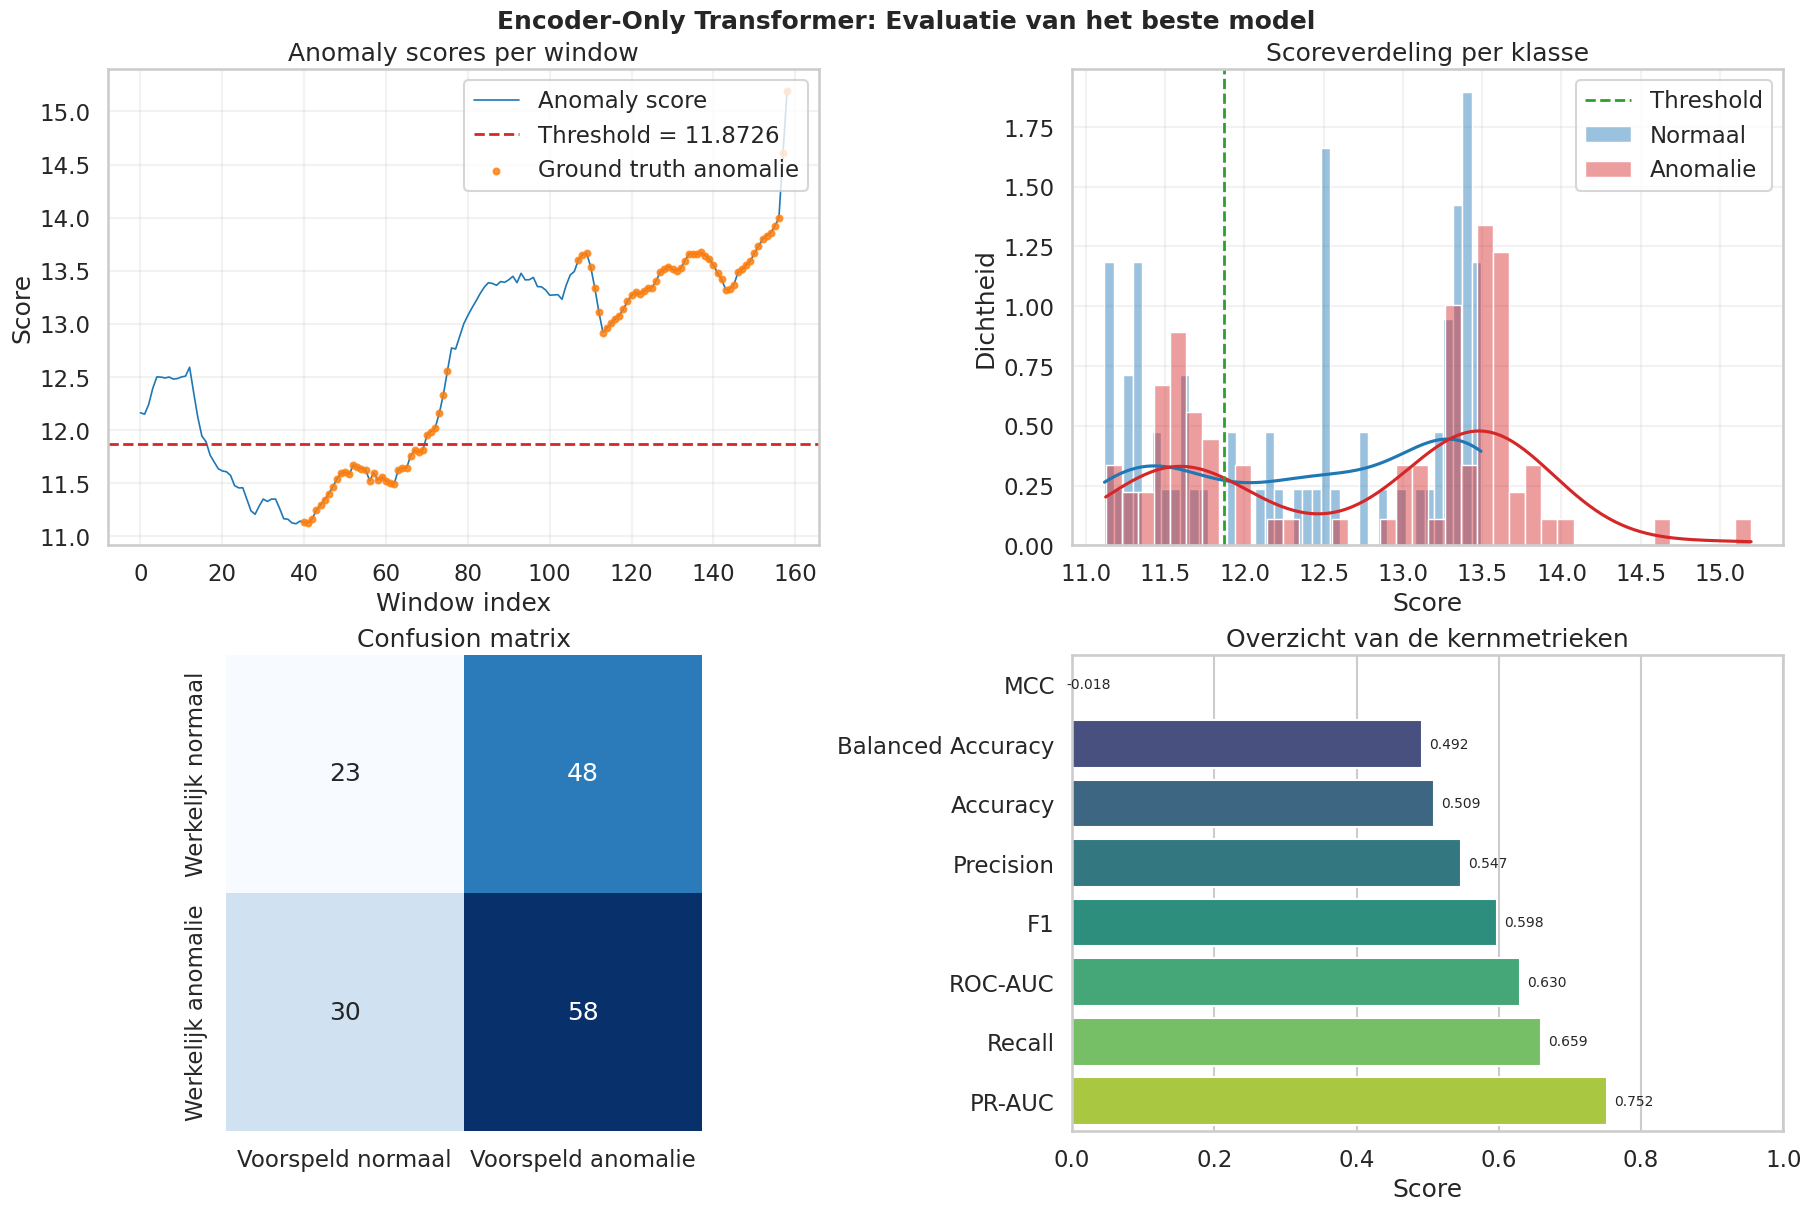

In [88]:
# Visualisaties
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle("Encoder-Only Transformer: Evaluatie van het beste model", fontsize=18, fontweight="bold")

# Plot 1: anomaly scores over de windows
ax1 = axes[0, 0]
ax1.plot(eval_scores_best, color="#1f77b4", linewidth=1.2, label="Anomaly score")
ax1.axhline(
    baseline_threshold_best,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {baseline_threshold_best:.4f}"
)

anom_idx = np.where(y_true_window == 1)[0]
ax1.scatter(
    anom_idx,
    eval_scores_best[anom_idx],
    s=18,
    color="#ff7f0e",
    alpha=0.8,
    label="Ground truth anomalie",
    zorder=5
)

ax1.set_title("Anomaly scores per window")
ax1.set_xlabel("Window index")
ax1.set_ylabel("Score")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.25)

# Plot 2: scoreverdeling per klasse
ax2 = axes[0, 1]
sns.histplot(
    eval_scores_best[y_true_window == 0],
    bins=40,
    kde=True,
    stat="density",
    color="#1f77b4",
    alpha=0.45,
    label="Normaal",
    ax=ax2
)
sns.histplot(
    eval_scores_best[y_true_window == 1],
    bins=40,
    kde=True,
    stat="density",
    color="#d62728",
    alpha=0.45,
    label="Anomalie",
    ax=ax2
)
ax2.axvline(baseline_threshold_best, color="#2ca02c", linestyle="--", linewidth=2, label="Threshold")
ax2.set_title("Scoreverdeling per klasse")
ax2.set_xlabel("Score")
ax2.set_ylabel("Dichtheid")
ax2.legend(loc="upper right")
ax2.grid(alpha=0.25)

# Plot 3: confusion matrix
ax3 = axes[1, 0]
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=["Voorspeld normaal", "Voorspeld anomalie"],
    yticklabels=["Werkelijk normaal", "Werkelijk anomalie"],
    ax=ax3
)
ax3.set_title("Confusion matrix")
ax3.set_xlabel("")
ax3.set_ylabel("")

# Plot 4: metric overview
ax4 = axes[1, 1]
metric_plot_df = metrics_best_df.sort_values("Value", ascending=True)

sns.barplot(
    data=metric_plot_df,
    x="Value",
    y="Metric",
    palette="viridis",
    ax=ax4
)

for i, value in enumerate(metric_plot_df["Value"]):
    ax4.text(min(value + 0.01, 1.02), i, f"{value:.3f}", va="center", fontsize=10)

ax4.set_xlim(0, max(1.0, metric_plot_df["Value"].max() + 0.15))
ax4.set_title("Overzicht van de kernmetrieken")
ax4.set_xlabel("Score")
ax4.set_ylabel("")

plt.show()